In [1]:
# Configurações e imports para avaliação de ranking com cross-encoders
import json
import random
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Avaliação de Ranking 

> Objetivo: avaliar modelos de cross-encoder no dataset `limit_dataset_pt.json` usando métricas de ranking.

Estrutura esperada do dataset:
- `passages`: lista de passagens candidatas
- `queries`: lista de consultas com:
  - `new_query`: texto da consulta
  - `query_type`: tipo da consulta
  - `is_selected`: vetor binário onde `1` indica passagem relevante

> `is_selected=0` nas passagens do dataset funciona como **hard negative**.

> Também adicionamos **easy negatives** amostrados de fontes externas (Wikipedia + notícias) para tornar a avaliação mais realista.

## Load dataset

In [2]:
with open("limit_dataset_pt_with_hard_negatives.json", "r", encoding="utf-8") as f:
    eval_items = json.load(f)

In [3]:
eval_items[0]

{'sample_id': 0,
 'new_query': 'Usando apenas as passagens fornecidas, liste TODAS as evidências e condições (em conjunto, sem omitir nenhuma) que justificam o argumento central do texto: para cada evidência, cite exatamente qual requisito/fator ela sustenta e como ela se conecta ao argumento. A resposta deve cobrir todas as evidências distribuídas nas passagens; se qualquer evidência ou condição relevante estiver faltando, a resposta estará incompleta.',
 'query_type': 'completude',
 'is_selected': [1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'passages': ['Ácidos nucleicos, que incluem o DNA (ácido desoxirribonucleico) e o RNA (ácido ribonucleico), são feitos de monômeros conhecidos como nucleotídeos. Cada nucleotídeo tem três componentes: um açúcar de 5 carbonos, um grupo fosfato e uma base nitrogenada. Se o açúcar é desoxirr

In [4]:
# Inspeção rápida do dataset real
query_types = pd.Series([q.get("query_type", "desconhecido") for q in eval_items]).value_counts()
print("Distribuição por tipo de query:")
display(query_types.to_frame("count"))

sample_count_by_type = pd.DataFrame(eval_items).groupby("query_type")["sample_id"].nunique().sort_values(ascending=False)
print("Amostras por tipo de query:")
display(sample_count_by_type.to_frame("n_amostras"))

example = eval_items[0]
print("Exemplo de query:")
print({
    "sample_id": example.get("sample_id"),
    "new_query": example.get("new_query", "")[:180] + ("..." if len(example.get("new_query", "")) > 180 else ""),
    "query_type": example.get("query_type", "desconhecido"),
    "num_relevant": int(sum(example.get("is_selected", []))),
    "num_passages_sample": len(example.get("passages", [])),
})

Distribuição por tipo de query:


,count
completude,2
expressao_booleana,2
contagem,2
temporal,2
abstracao,2


Amostras por tipo de query:


,n_amostras
query_type,
abstracao,2
completude,2
contagem,2
expressao_booleana,2
temporal,2


Exemplo de query:
{'sample_id': 0, 'new_query': 'Usando apenas as passagens fornecidas, liste TODAS as evidências e condições (em conjunto, sem omitir nenhuma) que justificam o argumento central do texto: para cada evidência, cit...', 'query_type': 'completude', 'num_relevant': 1, 'num_passages_sample': 41}


In [5]:
#corpus of easy negatives
#source 1: wikipedia

wikipedia_corpus = []
import datasets
wiki_dataset = datasets.load_dataset("dominguesm/wikipedia-ptbr-20230601", split="train")
for item in wiki_dataset:
    wikipedia_corpus.append(item['text'])
    if len(wikipedia_corpus) >= 1000:  # Limit to 1,000 entries for efficiency
        break

In [6]:
len(wikipedia_corpus)

1000

In [7]:
#source 2: news articles(https://www.kaggle.com/datasets/luisfcaldeira/folha-news-of-the-brazilian-newspaper-2024)
import pandas as pd
df = pd.read_csv("../FolhaArticles.csv", encoding="utf-8", sep="\t")

In [8]:
df.head()

,Title,Content,Url,Published,categories
0,Visões da batalha na Rússia e no Ocidente são ...,Quatro décadas de Guerra Fria e o renovado con...,https://www1.folha.uol.com.br/mundo/2019/06/vi...,2019-06-06 02:00:00.0000000,mundo
1,Bolsonaro é intimado pela PF sobre golpe e pod...,A Polícia Federal intimou Jair Bolsonaro (PL) ...,https://www1.folha.uol.com.br/poder/2024/02/pf...,2024-02-19 12:45:00.0000000,poder
2,Hayao Miyazaki passa a vida a limpo em O Menin...,Como vocês vivem? A pergunta parece ser feita ...,https://www1.folha.uol.com.br/ilustrada/2024/0...,2024-02-19 07:00:00.0000000,ilustrada
3,Série produzida pelo Estúdio Folha ganha Prêmi...,"A série ""Caminhos Proibidos"", produzida pelo E...",https://estudio.folha.uol.com.br/estudio/2024/...,2024-01-18 16:49:00.0000000,estudio
4,"Como é 'Crystal', do Cirque du Soleil, que vem...",Uma mulher expressa sua angústia dançando sobr...,https://www1.folha.uol.com.br/ilustrada/2024/0...,2024-02-19 15:15:00.0000000,ilustrada


In [9]:
news_corpus = df['Content'].tolist()[:1000]  # Limit to 1,000 entries for efficiency

In [10]:
# Consolida easy negatives e faz limpeza básica
easy_negatives = wikipedia_corpus + news_corpus
easy_negatives = [t for t in easy_negatives if isinstance(t, str) and t.strip()]

print(f"Easy negatives disponíveis: {len(easy_negatives)}")

Easy negatives disponíveis: 2000


## Funções de Avaliação (Comuns)

> Funções reutilizadas por Cross-Encoders e Bi-Encoders:
- montagem de candidatos
- ranqueamento
- métricas de avaliação
- sumarização por tipo de query e overall

In [11]:
from sentence_transformers import CrossEncoder, SentenceTransformer

def build_candidates(query_item: Dict, easy_negatives: List[str], n_easy: int, rng: random.Random):
    """Monta candidatos para a query: passagens da amostra + amostra de easy negatives."""
    passages = query_item.get("passages", [])
    labels = query_item.get("is_selected", [])

    if len(labels) != len(passages):
        raise ValueError(
            f"Tamanho de is_selected ({len(labels)}) diferente de passages ({len(passages)})."
        )

    texts = list(passages)
    y_true = [int(v) for v in labels]

    n_easy = min(n_easy, len(easy_negatives))
    sampled_easy = rng.sample(easy_negatives, n_easy) if n_easy > 0 else []
    texts.extend(sampled_easy)
    y_true.extend([0] * len(sampled_easy))

    return texts, y_true


def rank_with_cross_encoder(model: CrossEncoder, query_text: str, texts: List[str], batch_size: int = 16):
    pairs = [(query_text, t) for t in texts]
    scores = model.predict(
        pairs,
        convert_to_numpy=True,
        show_progress_bar=False,
        batch_size=batch_size,
    )
    ranking = np.argsort(-scores)
    return ranking, scores


def recall_at_k(y_true: List[int], ranking: np.ndarray, k: int) -> float:
    total_relevant = int(np.sum(y_true))
    if total_relevant == 0:
        return 0.0
    topk = ranking[:k]
    hits = int(np.sum([y_true[i] for i in topk]))
    return hits / total_relevant


def mrr(y_true: List[int], ranking: np.ndarray) -> float:
    for rank_pos, idx in enumerate(ranking, start=1):
        if y_true[idx] == 1:
            return 1.0 / rank_pos
    return 0.0


def average_precision(y_true: List[int], ranking: np.ndarray) -> float:
    total_relevant = int(np.sum(y_true))
    if total_relevant == 0:
        return 0.0

    hits = 0
    precision_sum = 0.0
    for rank_pos, idx in enumerate(ranking, start=1):
        if y_true[idx] == 1:
            hits += 1
            precision_sum += hits / rank_pos

    return precision_sum / total_relevant


def ndcg_at_k(y_true: List[int], ranking: np.ndarray, k: int) -> float:
    gains = np.array([y_true[idx] for idx in ranking[:k]], dtype=float)
    discounts = 1.0 / np.log2(np.arange(2, gains.size + 2))
    dcg = float(np.sum(gains * discounts))

    ideal_gains = np.sort(np.array(y_true, dtype=float))[::-1][:k]
    ideal_discounts = 1.0 / np.log2(np.arange(2, ideal_gains.size + 2))
    idcg = float(np.sum(ideal_gains * ideal_discounts))

    if idcg == 0.0:
        return 0.0
    return dcg / idcg


def summarize_per_query_metrics(per_query_df: pd.DataFrame) -> pd.DataFrame:
    metric_cols = [c for c in per_query_df.columns if c not in ["query_type", "num_relevant", "sample_id"]]

    overall = per_query_df[metric_cols].mean(numeric_only=True).to_frame().T
    overall.insert(0, "query_type", "overall")

    by_type = per_query_df.groupby("query_type", as_index=False)[metric_cols].mean(numeric_only=True)
    summary_df = pd.concat([overall, by_type], ignore_index=True)
    return summary_df


def evaluate_cross_encoder(
    model: CrossEncoder,
    eval_items: List[Dict],
    easy_negatives: List[str],
    n_easy_negatives: int = 200,
    k_values: Tuple[int, ...] = (5, 10),
    max_queries: int = None,
    seed: int = 42,
    predict_batch_size: int = 16,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    rng = random.Random(seed)
    rows = []

    eval_subset = eval_items if max_queries is None else eval_items[:max_queries]

    for query_item in tqdm(eval_subset, desc="Avaliando queries (cross)", leave=False):
        query_text = query_item.get("new_query", "")
        query_type = query_item.get("query_type", "desconhecido")

        texts, y_true = build_candidates(
            query_item=query_item,
            easy_negatives=easy_negatives,
            n_easy=n_easy_negatives,
            rng=rng,
        )

        ranking, _ = rank_with_cross_encoder(
            model,
            query_text,
            texts,
            batch_size=predict_batch_size,
        )

        row = {
            "sample_id": query_item.get("sample_id"),
            "query_type": query_type,
            "num_relevant": int(np.sum(y_true)),
            "MRR": mrr(y_true, ranking),
            "MAP": average_precision(y_true, ranking),
        }

        for k in k_values:
            row[f"Recall@{k}"] = recall_at_k(y_true, ranking, k)
            row[f"NDCG@{k}"] = ndcg_at_k(y_true, ranking, k)

        rows.append(row)

    per_query_df = pd.DataFrame(rows)
    summary_df = summarize_per_query_metrics(per_query_df)
    return per_query_df, summary_df


def evaluate_bi_encoder(
    model: SentenceTransformer,
    model_name: str,
    eval_items: List[Dict],
    easy_negatives: List[str],
    n_easy_negatives: int = 200,
    k_values: Tuple[int, ...] = (5, 10),
    max_queries: int = None,
    seed: int = 42,
    encode_batch_size: int = 32,
    truncate_dim: int = None,
    show_encode_progress: bool = False,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    rng = random.Random(seed)
    rows = []

    eval_subset = eval_items if max_queries is None else eval_items[:max_queries]

    use_e5_prefix = "e5" in model_name.lower()
    easy_inputs = list(easy_negatives)
    if use_e5_prefix:
        easy_inputs = [f"passage: {t}" for t in easy_inputs]

    easy_embs = None
    if len(easy_inputs) > 0:
        easy_embs = model.encode(
            easy_inputs,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=show_encode_progress,
            batch_size=encode_batch_size,
            truncate_dim=truncate_dim,
        ).astype(np.float32)

    # cache de embeddings das passagens por sample_id
    passage_cache = {}

    model_tag = model_name.split("/")[-1]
    for query_item in tqdm(eval_subset, desc=f"Avaliando queries (bi) [{model_tag}]", leave=True):
        query_text = query_item.get("new_query", "")
        query_type = query_item.get("query_type", "desconhecido")
        labels = query_item.get("is_selected", [])
        sample_id = query_item.get("sample_id")
        sample_passages = query_item.get("passages", [])

        if len(labels) != len(sample_passages):
            raise ValueError(
                f"Tamanho de is_selected ({len(labels)}) diferente de passages ({len(sample_passages)})."
            )

        y_true = [int(v) for v in labels]

        if sample_id not in passage_cache:
            passage_inputs = list(sample_passages)
            if use_e5_prefix:
                passage_inputs = [f"passage: {t}" for t in passage_inputs]
            passage_cache[sample_id] = model.encode(
                passage_inputs,
                convert_to_numpy=True,
                normalize_embeddings=True,
                show_progress_bar=show_encode_progress,
                batch_size=encode_batch_size,
                truncate_dim=truncate_dim,
            ).astype(np.float32)

        passage_embs = passage_cache[sample_id]

        n_easy = min(n_easy_negatives, len(easy_negatives))
        sampled_idx = rng.sample(range(len(easy_negatives)), n_easy) if n_easy > 0 else []

        if use_e5_prefix and not query_text.startswith("query:"):
            query_text = f"query: {query_text}"

        query_emb = model.encode(
            [query_text],
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=False,
            batch_size=1,
            truncate_dim=truncate_dim,
        ).astype(np.float32)

        if sampled_idx and easy_embs is not None:
            cand_embs = np.vstack([passage_embs, easy_embs[sampled_idx]])
            y_true = y_true + [0] * len(sampled_idx)
        else:
            cand_embs = passage_embs

        scores = np.matmul(query_emb, cand_embs.T).reshape(-1)
        ranking = np.argsort(-scores)

        row = {
            "sample_id": sample_id,
            "query_type": query_type,
            "num_relevant": int(np.sum(y_true)),
            "MRR": mrr(y_true, ranking),
            "MAP": average_precision(y_true, ranking),
        }

        for k in k_values:
            row[f"Recall@{k}"] = recall_at_k(y_true, ranking, k)
            row[f"NDCG@{k}"] = ndcg_at_k(y_true, ranking, k)

        rows.append(row)

    per_query_df = pd.DataFrame(rows)
    summary_df = summarize_per_query_metrics(per_query_df)
    return per_query_df, summary_df

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


## Avaliação de Cross-Encoders

> Esta seção contém:
- configuração dos modelos cross
- execução do benchmark cross

> Métricas usadas: `Recall@k`, `MRR`, `MAP` e `NDCG@k`.

> A avaliação combina:
- passagens do dataset (`hard negatives` + relevantes)
- passagens externas amostradas (`easy negatives`)

In [12]:
from sentence_transformers import CrossEncoder, SentenceTransformer

# Cross-encoders
MODEL_NAMES = [
    # "cross-encoder/ms-marco-MiniLM-L-6-v2",
    # "cross-encoder/ms-marco-MiniLM-L-12-v2",
    # "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1",
    "BAAI/bge-reranker-v2-m3",
]

# Parâmetros compartilhados
K_VALUES = (5, 10)
N_EASY_NEGATIVES = 100
MAX_QUERIES = None  # exemplo: 100 para avaliação mais rápida

print("Cross-encoders a avaliar:")
for m in MODEL_NAMES:
    print(" -", m)

Cross-encoders a avaliar:
 - BAAI/bge-reranker-v2-m3


In [13]:
# Executa benchmark: Cross-Encoders (BGE em GPU + checkpoints incrementais)
import gc
from pathlib import Path

try:
    import torch
except Exception:
    torch = None


In [14]:
len(eval_items[0]['passages']),len(eval_items[0]['is_selected'])

(41, 41)

In [15]:

checkpoint_dir = Path("outputs/ranking_eval/checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

cross_state_path = checkpoint_dir / "cross_state.json"
cross_summaries = []
cross_per_query = {}
completed_models = []

# Tenta retomar de checkpoint
if cross_state_path.exists():
    try:
        with open(cross_state_path, "r", encoding="utf-8") as f:
            state = json.load(f)
        completed_models = state.get("completed_models", [])

        for done_model in completed_models:
            safe_name = done_model.replace("/", "__")
            summary_path = checkpoint_dir / f"cross_summary_{safe_name}.csv"
            per_query_path = checkpoint_dir / f"cross_per_query_{safe_name}.csv"
            if summary_path.exists() and per_query_path.exists():
                summary_df_ckpt = pd.read_csv(summary_path)
                per_query_df_ckpt = pd.read_csv(per_query_path)
                cross_summaries.append(summary_df_ckpt)
                cross_per_query[f"cross::{done_model}"] = per_query_df_ckpt
    except Exception as e:
        print(f"Falha ao carregar checkpoint cross, iniciando do zero: {e}")
        completed_models = []
        cross_summaries = []
        cross_per_query = {}

if completed_models:
    print(f"Retomando cross checkpoint: {len(completed_models)} modelo(s) já concluído(s).")

for model_name in MODEL_NAMES:
    if model_name in completed_models:
        print(f"\nPulando (já concluído): {model_name}")
        continue

    print(f"\nCarregando cross-encoder: {model_name}")

    is_bge_m3 = model_name == "BAAI/bge-reranker-v2-m3"
    model_kwargs = {}
    predict_batch_size = 16
    prefer_gpu = bool(torch is not None and torch.cuda.is_available())

    if is_bge_m3:
        model_kwargs["max_length"] = 256
        if prefer_gpu:
            model_kwargs["device"] = "cuda"
            predict_batch_size = 8
            print("  -> BGE reranker em GPU (modo seguro: max_length=256, batch_size=8)")
        else:
            model_kwargs["device"] = "cpu"
            predict_batch_size = 4
            print("  -> BGE reranker em CPU (fallback: max_length=256, batch_size=4)")

    model = CrossEncoder(model_name, **model_kwargs)

    try:
        per_query_df, summary_df = evaluate_cross_encoder(
            model=model,
            eval_items=eval_items,
            easy_negatives=easy_negatives,
            n_easy_negatives=N_EASY_NEGATIVES,
            k_values=K_VALUES,
            max_queries=MAX_QUERIES,
            seed=RANDOM_SEED,
            predict_batch_size=predict_batch_size,
        )
    except RuntimeError as e:
        # Fallback automático para OOM do BGE na GPU
        if is_bge_m3 and prefer_gpu and "out of memory" in str(e).lower():
            print("  -> OOM na GPU para BGE. Reexecutando em CPU...")
            del model
            gc.collect()
            if torch is not None and torch.cuda.is_available():
                torch.cuda.empty_cache()

            model = CrossEncoder(model_name, device="cpu", max_length=256)
            per_query_df, summary_df = evaluate_cross_encoder(
                model=model,
                eval_items=eval_items,
                easy_negatives=easy_negatives,
                n_easy_negatives=N_EASY_NEGATIVES,
                k_values=K_VALUES,
                max_queries=MAX_QUERIES,
                seed=RANDOM_SEED,
                predict_batch_size=4,
            )
        else:
            raise

    display_name = f"cross::{model_name}"
    cross_per_query[display_name] = per_query_df
    summary_df.insert(0, "model", display_name)
    cross_summaries.append(summary_df)

    # Salva checkpoint incremental por modelo
    safe_name = model_name.replace("/", "__")
    summary_path = checkpoint_dir / f"cross_summary_{safe_name}.csv"
    per_query_path = checkpoint_dir / f"cross_per_query_{safe_name}.csv"
    summary_df.to_csv(summary_path, index=False)
    per_query_df.to_csv(per_query_path, index=False)

    completed_models.append(model_name)
    with open(cross_state_path, "w", encoding="utf-8") as f:
        json.dump({"completed_models": completed_models}, f, ensure_ascii=False, indent=2)

    cross_partial_df = pd.concat(cross_summaries, ignore_index=True)
    cross_partial_df.to_csv(checkpoint_dir / "cross_results_partial.csv", index=False)
    print(f"  -> checkpoint salvo ({len(completed_models)}/{len(MODEL_NAMES)})")

    del model
    gc.collect()
    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()

cross_results_df = pd.concat(cross_summaries, ignore_index=True)
cross_results_df.to_csv(checkpoint_dir / "cross_results_latest_checkpoint.csv", index=False)
cross_results_df


Carregando cross-encoder: BAAI/bge-reranker-v2-m3
  -> BGE reranker em GPU (modo seguro: max_length=256, batch_size=8)


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Avaliando queries (cross):   0%|          | 0/10 [00:00<?, ?it/s]

  -> checkpoint salvo (1/1)


,model,query_type,MRR,MAP,Recall@5,NDCG@5,Recall@10,NDCG@10
0,cross::BAAI/bge-reranker-v2-m3,overall,0.039349,0.039349,0.0,0.0,0.1,0.031546
1,cross::BAAI/bge-reranker-v2-m3,abstracao,0.066071,0.066071,0.0,0.0,0.5,0.157732
2,cross::BAAI/bge-reranker-v2-m3,completude,0.019899,0.019899,0.0,0.0,0.0,0.000000
3,cross::BAAI/bge-reranker-v2-m3,contagem,0.046254,0.046254,0.0,0.0,0.0,0.000000
4,cross::BAAI/bge-reranker-v2-m3,expressao_booleana,0.032958,0.032958,0.0,0.0,0.0,0.000000
5,cross::BAAI/bge-reranker-v2-m3,temporal,0.031566,0.031566,0.0,0.0,0.0,0.000000


## Inferência (BGE Reranker)

> Use esta seção para inspecionar o ranking do BGE em queries do dataset.

Passos:
- carregar o modelo BGE para inferência (GPU quando disponível)
- escolher uma query do `eval_items`
- visualizar top-k com score e relevância real

In [32]:
#increase passage display limit for better visualization
pd.set_option('display.max_colwidth', 500)

# Inferência interativa no dataset: escolha uma query e veja o ranking
BGE_QUERY_INDEX = 14   # ajuste o índice da query em eval_items
BGE_TOP_K = 10        # quantos resultados mostrar

try:
    import torch
except Exception:
    torch = None

# Caso a célula de carregamento não tenha sido executada antes
if "BGE_INFER_MODEL_NAME" not in globals():
    BGE_INFER_MODEL_NAME = "BAAI/bge-reranker-v2-m3"
if "BGE_INFER_MAX_LENGTH" not in globals():
    BGE_INFER_MAX_LENGTH = 256

if "BGE_INFER_MODEL" not in globals() or "bge_infer_device" not in globals():
    from sentence_transformers import CrossEncoder

    prefer_gpu = bool(torch is not None and torch.cuda.is_available())
    try:
        BGE_INFER_MODEL = CrossEncoder(
            BGE_INFER_MODEL_NAME,
            device="cuda" if prefer_gpu else "cpu",
            max_length=BGE_INFER_MAX_LENGTH,
        )
        bge_infer_device = "cuda" if prefer_gpu else "cpu"
    except RuntimeError as e:
        if prefer_gpu and "out of memory" in str(e).lower():
            print("OOM ao carregar BGE na GPU. Fazendo fallback para CPU...")
            if torch is not None and torch.cuda.is_available():
                torch.cuda.empty_cache()
            BGE_INFER_MODEL = CrossEncoder(
                BGE_INFER_MODEL_NAME,
                device="cpu",
                max_length=BGE_INFER_MAX_LENGTH,
            )
            bge_infer_device = "cpu"
        else:
            raise

if BGE_QUERY_INDEX < 0 or BGE_QUERY_INDEX >= len(eval_items):
    raise ValueError(f"BGE_QUERY_INDEX fora do intervalo: 0..{len(eval_items)-1}")

item = eval_items[BGE_QUERY_INDEX]
query_text = item.get("new_query", "")
query_type = item.get("query_type", "desconhecido")
passages = item.get("passages", [])
labels = [int(v) for v in item.get("is_selected", [])]

if len(passages) != len(labels):
    raise ValueError("Quantidade de passages diferente de is_selected para a query escolhida.")

pairs = [(query_text, p) for p in passages]
scores = BGE_INFER_MODEL.predict(
    pairs,
    convert_to_numpy=True,
    show_progress_bar=False,
    batch_size=8 if bge_infer_device == "cuda" else 4,
)

ranking = np.argsort(-scores)
top_idx = ranking[:BGE_TOP_K]

infer_df = pd.DataFrame({
    "rank": np.arange(1, len(top_idx) + 1),
    "passage_idx": top_idx,
    "score": scores[top_idx],
    "is_relevant": [labels[i] for i in top_idx],
    "passage": [passages[i] for i in top_idx],
})

print(f"Modelo: {BGE_INFER_MODEL_NAME}")
print(f"Device ativo: {bge_infer_device}")
print(f"Query index: {BGE_QUERY_INDEX}")
print(f"Sample ID: {item.get('sample_id')}")
print(f"Query type: {query_type}")
print(f"Query: {query_text}")
print(f"Relevantes totais na amostra: {sum(labels)}")

Modelo: BAAI/bge-reranker-v2-m3
Device ativo: cuda
Query index: 14
Sample ID: 2
Query type: abstracao
Query: Em termos conceituais, quais passagens fornecem evidência de que a União Soviética buscava estabelecer/expandir sua esfera de influência no pós-Segunda Guerra por meio de governos subordinados (isto é, “dependentes” politicamente), e não apenas de uma estratégia militar pontual?
Relevantes totais na amostra: 4


In [ ]:
#completude
# Liste todas as evidências, a partir das passagens fornecidas, sobre o Projeto Manhattan: (1) seu objetivo/propósito, 
# (2) o período e quem o controlou/dirigiu, (3) quais países deram apoio e quem liderou (por cargo),
# (4) quem foi o diretor do Laboratório de Los Alamos e sua função, (5) quando e onde foi detonada a primeira bomba 
# atômica (inclua a data e o local), e (6) uma justificativa apresentada nas passagens para a escolha de um local do projeto
# (qual local e por quê).

infer_df

,rank,passage_idx,score,is_relevant,passage
0,1,7,0.998210,1,"Projeto Manhattan. O Projeto Manhattan foi um empreendimento de pesquisa e desenvolvimento durante a Segunda Guerra Mundial que produziu as primeiras armas nucleares. Foi liderado pelos Estados Unidos com o apoio do Reino Unido e do Canadá. De 1942 a 1946, o projeto esteve sob a direção do Major-General Leslie Groves do Corpo de Engenheiros do Exército dos EUA. O físico nuclear Robert Oppenheimer foi o diretor do Laboratório de Los Alamos que projetou as bombas propriamente ditas. A componen..."
1,2,3,0.991925,1,"O Projeto Manhattan foi o nome dado a um projeto conduzido durante a Segunda Guerra Mundial, para desenvolver a primeira bomba atômica. Refere-se especificamente ao período do projeto de 194…2-1946 sob o controle do Corpo de Engenheiros do Exército dos EUA, sob a administração do General Leslie R. Groves."
2,3,5,0.977459,1,"O Projeto Manhattan. Esta fotografia, antes classificada, apresenta a primeira bomba atômica — uma arma que os cientistas atômicos apelidaram de Gadget. A era nuclear começou em 16 de julho de 1945, quando foi detonada no deserto do Novo México."
3,4,8,0.895003,1,":\n\nEm junho de 1942, o Corpo de Engenheiros do Exército dos Estados Unidos iniciou o Projeto Manhattan – o nome secreto para as 2 bombas atômicas."
4,5,1,0.881604,0,O Projeto Manhattan e sua bomba atômica ajudaram a pôr fim à Segunda Guerra Mundial. Seu legado de usos pacíficos da energia atômica continua a ter um impacto na história e na ciência.
5,6,2,0.862819,1,"Ensaio sobre o Projeto Manhattan - O Projeto Manhattan\n\nO Projeto Manhattan visava determinar se a fabricação de uma bomba atômica era possível. O sucesso deste projeto mudaria para sempre o mundo, tornando conhecido o fato de que algo tão poderoso pode ser feito pelo homem."
6,7,4,0.299214,0,"versões de cada volume, bem como sites complementares. O primeiro site – O Projeto Manhattan: Uma História Interativa – está disponível no site do Escritório de História e Recursos de Patrimônio, http://www.cfo.doe.gov/me70/history. O Escritório de História e Recursos de Patrimônio e a Administração Nacional de Segurança Nuclear"
7,8,9,0.213154,1,"Uma das principais razões pelas quais Hanford foi selecionada como local para o Reator B do Projeto Manhattan foi sua proximidade com o Rio Columbia, o maior rio que deságua no Oceano Pacífico a partir da costa da América do Norte."
8,9,0,0.154542,0,A presença da comunicação entre mentes científicas foi tão importante para o sucesso do Projeto Manhattan quanto o intelecto científico. A única nuvem pairando sobre a impressionante conquista dos pesquisadores e engenheiros atômicos é o que seu sucesso realmente significou: centenas de milhares de vidas inocentes obliteradas.
9,10,6,0.135126,0,Também não tentará substituir a literatura extraordinariamente rica sobre as bombas atômicas e o fim da Segunda Guerra Mundial. Esta coleção não tenta documentar as origens e o desenvolvimento do Projeto Manhattan.


In [ ]:
#abstracao
#Query: Em termos conceituais, quais passagens fornecem evidência de que a União Soviética buscava estabelecer/expandir 
# sua esfera de influência no pós-Segunda Guerra por meio de governos subordinados (isto é, “dependentes” politicamente), 
# e não apenas de uma estratégia militar pontual?
infer_df

,rank,passage_idx,score,is_relevant,passage
0,1,5,0.244009,1,"Portanto, se algo, eles apertaram ainda mais seu controle, com a Hungria em 1956, a Tchecoslováquia em 1968 e a construção do Muro de Berlim sendo todos exemplos. Após Stalin, não foi tanto o desejo de estender o poder soviético quanto a paranoia de perdê-lo que manteve o desejo soviético de controlar a Europa Oriental."
1,2,1,0.079171,0,":\n\nA República Popular Tuvan foi proclamada independente em 1921 e foi um estado satélite da União Soviética até sua anexação em 1944 pela União Soviética. Outro estado satélite soviético inicial na Ásia foi a República do Extremo Oriente, de curta duração, na Sibéria. Pós-Segunda Guerra Mundial."
2,3,6,0.016713,0,Existem 3 razões principais pelas quais Stalin queria controlar a Europa Oriental. 1.) A Rússia historicamente não tem uma fronteira segura. 2.) Eles queriam estabelecer países satélites. 3.)
3,4,9,0.011454,0,"Não apenas a Europa Oriental, Stalin queria controlar o mundo criando um império baseado no Comunismo. Foi assim que entraram em conflito com os EUA, que pretendiam controlar o mundo construindo um império baseado no Capitalismo. É sobre isso que se trata a Guerra Fria."
4,5,8,0.005497,1,"Além disso, a Rússia havia sido vítima de ataques do Ocidente diversas vezes. Em 1914 e 1941 a Alemanha atacou a Rússia através da Polônia. Para Stalin, o passado era um indicador confiável do que o futuro poderia reservar. Stalin pensava que ter controle sobre a Europa Oriental poderia diminuir significativamente essa ameaça. Apesar disso, foi acordado na Conferência de Yalta, com o consentimento de Stalin, que todos os países libertados da Alemanha Nazista teriam o direito de ser democráti..."
5,6,2,0.004335,1,":\n\nEstado satélite. O termo ""estado satélite"" designa um país que é formalmente independente no mundo, mas sob forte influência ou controle político, econômico e militar de outro país. O termo foi cunhado por analogia a objetos planetários orbitando um objeto maior, como luas menores girando em torno de planetas maiores, e é usado principalmente para se referir aos países da Europa Central e Oriental do Pacto de Varsóvia durante a Guerra Fria ou à Mongólia ou Tuva Tannu entre 1924 e 1990, ..."
6,7,0,0.001756,0,"Traição Ocidental. O conceito de Traição Ocidental refere-se à visão de que o Reino Unido e a França não cumpriram suas obrigações legais, diplomáticas, militares e morais em relação às nações Tcheca e Polonesa durante o prelúdio e as consequências da Segunda Guerra Mundial."
7,8,4,0.001246,1,":\n\nUma entrevista com Anne Applebaum sobre seu novo livro, O Esmagamento da Europa Oriental. Tanques construídos pela União Soviética entram em ação em uma rua de Budapeste tomada pela fumaça durante a rebelião da Hungria contra o governo satélite comunista em outubro de 1956."
8,9,3,0.000149,0,*Para obter matérias-primas.*\n*Para aliviar o desemprego.*\n*Para expandir o poder e a reputação da Inglaterra.*\n*Para converter nativos ao protestantismo.*
9,10,7,0.000021,0,Por que as Nações Unidas enviaram tropas para a Coreia em 1950? Elas queriam conter e repelir os invasores comunistas do Norte. Por que o conflito árabe-israelense foi considerado parte da Guerra Fria?


In [ ]:
# Carrega BGE para inferência (GPU-first, com fallback em OOM)
from sentence_transformers import CrossEncoder

BGE_INFER_MODEL_NAME = "BAAI/bge-reranker-v2-m3"
BGE_INFER_MAX_LENGTH = 256

try:
    import torch
except Exception:
    torch = None

prefer_gpu = bool(torch is not None and torch.cuda.is_available())
bge_infer_device = "cuda" if prefer_gpu else "cpu"

def load_bge_infer_model(device: str = "cuda", max_length: int = 256):
    try:
        model = CrossEncoder(BGE_INFER_MODEL_NAME, device=device, max_length=max_length)
        return model, device
    except RuntimeError as e:
        if device == "cuda" and "out of memory" in str(e).lower():
            print("OOM ao carregar BGE na GPU. Fazendo fallback para CPU...")
            if torch is not None and torch.cuda.is_available():
                torch.cuda.empty_cache()
            model = CrossEncoder(BGE_INFER_MODEL_NAME, device="cpu", max_length=max_length)
            return model, "cpu"
        raise

BGE_INFER_MODEL, bge_infer_device = load_bge_infer_model(
    device=bge_infer_device,
    max_length=BGE_INFER_MAX_LENGTH,
)

print(f"Modelo de inferência carregado: {BGE_INFER_MODEL_NAME}")
print(f"Device ativo: {bge_infer_device}")

## Avaliação de Bi-Encoders

> Estrutura alinhada com a seção de cross-encoders:
- configuração dos modelos
- execução da avaliação
- consolidação final dos resultados

In [15]:
# Configuração + benchmark: Bi-Encoders (GPU-first para Granite, com checkpoint incremental)
import gc
from pathlib import Path

try:
    import torch
except Exception:
    torch = None

checkpoint_dir = Path("outputs/ranking_eval/checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

BI_ENCODER_MODEL_NAMES = [
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    "intfloat/multilingual-e5-base",
    "ibm-granite/granite-embedding-311m-multilingual-r2",
]

print("Bi-encoders a avaliar:")
for model_name in BI_ENCODER_MODEL_NAMES:
    print(" -", model_name)

bi_state_path = checkpoint_dir / "bi_state.json"
bi_summaries = []
bi_per_query = {}
completed_models = []

# Tenta retomar de checkpoint
if bi_state_path.exists():
    try:
        with open(bi_state_path, "r", encoding="utf-8") as f:
            state = json.load(f)
        completed_models = state.get("completed_models", [])

        for done_model in completed_models:
            safe_name = done_model.replace("/", "__")
            summary_path = checkpoint_dir / f"bi_summary_{safe_name}.csv"
            per_query_path = checkpoint_dir / f"bi_per_query_{safe_name}.csv"
            if summary_path.exists() and per_query_path.exists():
                summary_df_ckpt = pd.read_csv(summary_path)
                per_query_df_ckpt = pd.read_csv(per_query_path)
                bi_summaries.append(summary_df_ckpt)
                bi_per_query[f"bi::{done_model}"] = per_query_df_ckpt
    except Exception as e:
        print(f"Falha ao carregar checkpoint bi, iniciando do zero: {e}")
        completed_models = []
        bi_summaries = []
        bi_per_query = {}

if completed_models:
    print(f"Retomando bi checkpoint: {len(completed_models)} modelo(s) já concluído(s).")

for model_name in BI_ENCODER_MODEL_NAMES:
    if model_name in completed_models:
        print(f"\nPulando (já concluído): {model_name}")
        continue

    print(f"\nCarregando bi-encoder: {model_name}")

    model_kwargs = {}
    encode_batch_size = 32
    truncate_dim = None
    show_encode_progress = False

    is_granite = "granite-embedding-311m" in model_name
    prefer_gpu = bool(torch is not None and torch.cuda.is_available())

    if is_granite:
        truncate_dim = 256
        show_encode_progress = True
        if prefer_gpu:
            model_kwargs["device"] = "cuda"
            encode_batch_size = 4
            print("  -> Granite em GPU (modo seguro: batch=4, truncate_dim=256)")
        else:
            model_kwargs["device"] = "cpu"
            encode_batch_size = 8
            print("  -> Granite em CPU (modo seguro: batch=8, truncate_dim=256)")
        print("  -> exibindo progresso do encoding para o Granite")

    model = SentenceTransformer(model_name, **model_kwargs)
    if is_granite:
        model.max_seq_length = 384

    try:
        per_query_df, summary_df = evaluate_bi_encoder(
            model=model,
            model_name=model_name,
            eval_items=eval_items,
            easy_negatives=easy_negatives,
            n_easy_negatives=N_EASY_NEGATIVES,
            k_values=K_VALUES,
            max_queries=MAX_QUERIES,
            seed=RANDOM_SEED,
            encode_batch_size=encode_batch_size,
            truncate_dim=truncate_dim,
            show_encode_progress=show_encode_progress,
        )
    except RuntimeError as e:
        # Fallback automático para OOM do Granite em GPU
        if is_granite and prefer_gpu and "out of memory" in str(e).lower():
            print("  -> OOM na GPU detectado para Granite. Reexecutando em CPU...")
            del model
            gc.collect()
            if torch is not None and torch.cuda.is_available():
                torch.cuda.empty_cache()

            model = SentenceTransformer(model_name, device="cpu")
            model.max_seq_length = 384

            per_query_df, summary_df = evaluate_bi_encoder(
                model=model,
                model_name=model_name,
                eval_items=eval_items,
                easy_negatives=easy_negatives,
                n_easy_negatives=N_EASY_NEGATIVES,
                k_values=K_VALUES,
                max_queries=MAX_QUERIES,
                seed=RANDOM_SEED,
                encode_batch_size=8,
                truncate_dim=256,
                show_encode_progress=True,
            )
        else:
            raise

    display_name = f"bi::{model_name}"
    bi_per_query[display_name] = per_query_df
    summary_df.insert(0, "model", display_name)
    bi_summaries.append(summary_df)

    # Salva checkpoint incremental por modelo
    safe_name = model_name.replace("/", "__")
    summary_path = checkpoint_dir / f"bi_summary_{safe_name}.csv"
    per_query_path = checkpoint_dir / f"bi_per_query_{safe_name}.csv"
    summary_df.to_csv(summary_path, index=False)
    per_query_df.to_csv(per_query_path, index=False)

    completed_models.append(model_name)
    with open(bi_state_path, "w", encoding="utf-8") as f:
        json.dump({"completed_models": completed_models}, f, ensure_ascii=False, indent=2)

    bi_partial_df = pd.concat(bi_summaries, ignore_index=True)
    bi_partial_df.to_csv(checkpoint_dir / "bi_results_partial.csv", index=False)
    print(f"  -> checkpoint salvo ({len(completed_models)}/{len(BI_ENCODER_MODEL_NAMES)})")

    del model
    gc.collect()
    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()

bi_results_df = pd.concat(bi_summaries, ignore_index=True)
bi_results_df.to_csv(checkpoint_dir / "bi_results_latest_checkpoint.csv", index=False)
bi_results_df

Bi-encoders a avaliar:
 - sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
 - intfloat/multilingual-e5-base
 - ibm-granite/granite-embedding-311m-multilingual-r2

Carregando bi-encoder: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2612.12it/s]
Avaliando queries (bi) [paraphrase-multilingual-MiniLM-L12-v2]: 100%|██████████| 125/125 [00:00<00:00, 192.28it/s]


  -> checkpoint salvo (1/3)

Carregando bi-encoder: intfloat/multilingual-e5-base


Avaliando queries (bi) [multilingual-e5-base]: 100%|██████████| 125/125 [00:01<00:00, 108.85it/s]


  -> checkpoint salvo (2/3)

Carregando bi-encoder: ibm-granite/granite-embedding-311m-multilingual-r2
  -> Granite em GPU (modo seguro: batch=4, truncate_dim=256)
  -> exibindo progresso do encoding para o Granite


Batches: 100%|██████████| 3/3 [00:00<00:00, 126.37it/s]
Avaliando queries (bi) [granite-embedding-311m-multilingual-r2]: 100%|██████████| 125/125 [00:01<00:00, 91.82it/s]


  -> checkpoint salvo (3/3)


,model,query_type,MRR,MAP,Recall@5,NDCG@5,Recall@10,NDCG@10
0,bi::sentence-transformers/paraphrase-multiling...,overall,0.689852,0.598798,0.644848,0.595303,0.924190,0.710751
1,bi::sentence-transformers/paraphrase-multiling...,abstracao,0.695023,0.583137,0.573524,0.555896,0.900000,0.690607
2,bi::sentence-transformers/paraphrase-multiling...,completude,0.677762,0.599342,0.544714,0.563074,0.934286,0.715893
3,bi::sentence-transformers/paraphrase-multiling...,contagem,0.662857,0.591724,0.644667,0.584611,0.890000,0.698802
4,bi::sentence-transformers/paraphrase-multiling...,expressao_booleana,0.710222,0.622385,0.740667,0.652039,0.936667,0.730404
5,bi::sentence-transformers/paraphrase-multiling...,temporal,0.703397,0.597402,0.720667,0.620894,0.960000,0.718050
6,bi::intfloat/multilingual-e5-base,overall,0.667497,0.603059,0.679790,0.613697,0.871038,0.692999
7,bi::intfloat/multilingual-e5-base,abstracao,0.560008,0.532836,0.653905,0.553308,0.803333,0.611561
8,bi::intfloat/multilingual-e5-base,completude,0.680381,0.592988,0.535714,0.564268,0.879857,0.694227
9,bi::intfloat/multilingual-e5-base,contagem,0.695236,0.621813,0.686667,0.627489,0.830000,0.697269


## Avaliacao conjunta

In [16]:
# Consolidação final (cross + bi)
results_df = pd.concat([cross_results_df, bi_results_df], ignore_index=True)
per_query_by_model = {**cross_per_query, **bi_per_query}

print("Resumo consolidado:")
print(f" - Modelos cross: {len(cross_per_query)}")
print(f" - Modelos bi: {len(bi_per_query)}")
print(f" - Linhas em results_df: {len(results_df)}")

results_df

Resumo consolidado:
 - Modelos cross: 4
 - Modelos bi: 3
 - Linhas em results_df: 42


,model,query_type,MRR,MAP,Recall@5,NDCG@5,Recall@10,NDCG@10
0,cross::cross-encoder/ms-marco-MiniLM-L-6-v2,overall,0.527724,0.431414,0.512638,0.449073,0.642581,0.504085
1,cross::cross-encoder/ms-marco-MiniLM-L-6-v2,abstracao,0.244976,0.211929,0.329143,0.226358,0.428190,0.270415
2,cross::cross-encoder/ms-marco-MiniLM-L-6-v2,completude,0.549525,0.418923,0.440048,0.429918,0.612714,0.489553
3,cross::cross-encoder/ms-marco-MiniLM-L-6-v2,contagem,0.469791,0.398215,0.460000,0.401815,0.595333,0.467635
4,cross::cross-encoder/ms-marco-MiniLM-L-6-v2,expressao_booleana,0.834309,0.714122,0.767333,0.741757,0.846667,0.782008
5,cross::cross-encoder/ms-marco-MiniLM-L-6-v2,temporal,0.540017,0.413879,0.566667,0.445519,0.730000,0.510814
6,cross::cross-encoder/ms-marco-MiniLM-L-12-v2,overall,0.500683,0.410708,0.497457,0.427777,0.638800,0.489107
7,cross::cross-encoder/ms-marco-MiniLM-L-12-v2,abstracao,0.315020,0.264582,0.305810,0.270006,0.351524,0.289116
8,cross::cross-encoder/ms-marco-MiniLM-L-12-v2,completude,0.479035,0.370606,0.407476,0.366405,0.651143,0.468880
9,cross::cross-encoder/ms-marco-MiniLM-L-12-v2,contagem,0.433897,0.366188,0.454667,0.373664,0.613333,0.449576


In [17]:
# Salva resultados em nova pasta
from pathlib import Path
from datetime import datetime

output_dir = Path("outputs/ranking_eval")
output_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Tabelas principais
cross_results_df.to_csv(output_dir / "cross_results_latest.csv", index=False)
bi_results_df.to_csv(output_dir / "bi_results_latest.csv", index=False)
results_df.to_csv(output_dir / "results_latest.csv", index=False)

# Snapshots versionados
cross_results_df.to_csv(output_dir / f"cross_results_{timestamp}.csv", index=False)
bi_results_df.to_csv(output_dir / f"bi_results_{timestamp}.csv", index=False)
results_df.to_csv(output_dir / f"results_{timestamp}.csv", index=False)

# Metadados do experimento
metadata = {
    "timestamp": timestamp,
    "cross_models": MODEL_NAMES,
    "bi_models": BI_ENCODER_MODEL_NAMES,
    "k_values": list(K_VALUES),
    "n_easy_negatives": int(N_EASY_NEGATIVES),
    "max_queries": MAX_QUERIES,
    "n_rows_cross": int(len(cross_results_df)),
    "n_rows_bi": int(len(bi_results_df)),
    "n_rows_total": int(len(results_df)),
}

with open(output_dir / "run_metadata_latest.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

with open(output_dir / f"run_metadata_{timestamp}.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"Resultados salvos em: {output_dir.resolve()}")
print("Arquivos latest:")
print(" - cross_results_latest.csv")
print(" - bi_results_latest.csv")
print(" - results_latest.csv")
print(" - run_metadata_latest.json")

Resultados salvos em: /home/Projects/BTG/Limit/outputs/ranking_eval
Arquivos latest:
 - cross_results_latest.csv
 - bi_results_latest.csv
 - results_latest.csv
 - run_metadata_latest.json


In [18]:
# Ranking final (overall) e comparação por tipo de query
overall_df = results_df[results_df["query_type"] == "overall"].copy()
overall_df = overall_df.sort_values(["NDCG@10", "MRR"], ascending=False)
print("Resultados gerais (overall):")
display(overall_df.reset_index(drop=True))

print("\nMelhor modelo por NDCG@10:")
display(overall_df[["model", "NDCG@10", "MRR", "MAP", "Recall@5", "Recall@10"]].head(1))

print("\nMatriz por tipo de query (NDCG@10):")
pivot_ndcg10 = results_df[results_df["query_type"] != "overall"].pivot(
    index="model", columns="query_type", values="NDCG@10"
 )
display(pivot_ndcg10)

Resultados gerais (overall):


,model,query_type,MRR,MAP,Recall@5,NDCG@5,Recall@10,NDCG@10
0,cross::BAAI/bge-reranker-v2-m3,overall,0.765543,0.686267,0.778924,0.708175,0.967257,0.786561
1,bi::ibm-granite/granite-embedding-311m-multili...,overall,0.740590,0.668179,0.752771,0.685411,0.952400,0.767423
2,bi::sentence-transformers/paraphrase-multiling...,overall,0.689852,0.598798,0.644848,0.595303,0.924190,0.710751
3,bi::intfloat/multilingual-e5-base,overall,0.667497,0.603059,0.679790,0.613697,0.871038,0.692999
4,cross::cross-encoder/ms-marco-MiniLM-L-6-v2,overall,0.527724,0.431414,0.512638,0.449073,0.642581,0.504085
5,cross::cross-encoder/ms-marco-MiniLM-L-12-v2,overall,0.500683,0.410708,0.497457,0.427777,0.638800,0.489107
6,cross::cross-encoder/mmarco-mMiniLMv2-L12-H384-v1,overall,0.506901,0.408224,0.456162,0.412876,0.591838,0.469270



Melhor modelo por NDCG@10:


,model,NDCG@10,MRR,MAP,Recall@5,Recall@10
18,cross::BAAI/bge-reranker-v2-m3,0.786561,0.765543,0.686267,0.778924,0.967257



Matriz por tipo de query (NDCG@10):


query_type,abstracao,completude,contagem,expressao_booleana,temporal
model,,,,,
bi::ibm-granite/granite-embedding-311m-multilingual-r2,0.779169,0.790360,0.725047,0.749664,0.792875
bi::intfloat/multilingual-e5-base,0.611561,0.694227,0.697269,0.736004,0.725935
bi::sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2,0.690607,0.715893,0.698802,0.730404,0.718050
cross::BAAI/bge-reranker-v2-m3,0.735876,0.792886,0.766754,0.835177,0.802109
cross::cross-encoder/mmarco-mMiniLMv2-L12-H384-v1,0.299818,0.382794,0.506746,0.769715,0.387278
cross::cross-encoder/ms-marco-MiniLM-L-12-v2,0.289116,0.468880,0.449576,0.749545,0.488417
cross::cross-encoder/ms-marco-MiniLM-L-6-v2,0.270415,0.489553,0.467635,0.782008,0.510814


,model,NDCG@10,MRR,MAP,Recall@10,Recall@5,NDCG@5
18,cross::BAAI/bge-reranker-v2-m3,0.786561,0.765543,0.686267,0.967257,0.778924,0.708175
36,bi::ibm-granite/granite-embedding-311m-multili...,0.767423,0.740590,0.668179,0.952400,0.752771,0.685411
24,bi::sentence-transformers/paraphrase-multiling...,0.710751,0.689852,0.598798,0.924190,0.644848,0.595303
30,bi::intfloat/multilingual-e5-base,0.692999,0.667497,0.603059,0.871038,0.679790,0.613697
0,cross::cross-encoder/ms-marco-MiniLM-L-6-v2,0.504085,0.527724,0.431414,0.642581,0.512638,0.449073
6,cross::cross-encoder/ms-marco-MiniLM-L-12-v2,0.489107,0.500683,0.410708,0.638800,0.497457,0.427777
12,cross::cross-encoder/mmarco-mMiniLMv2-L12-H384-v1,0.469270,0.506901,0.408224,0.591838,0.456162,0.412876


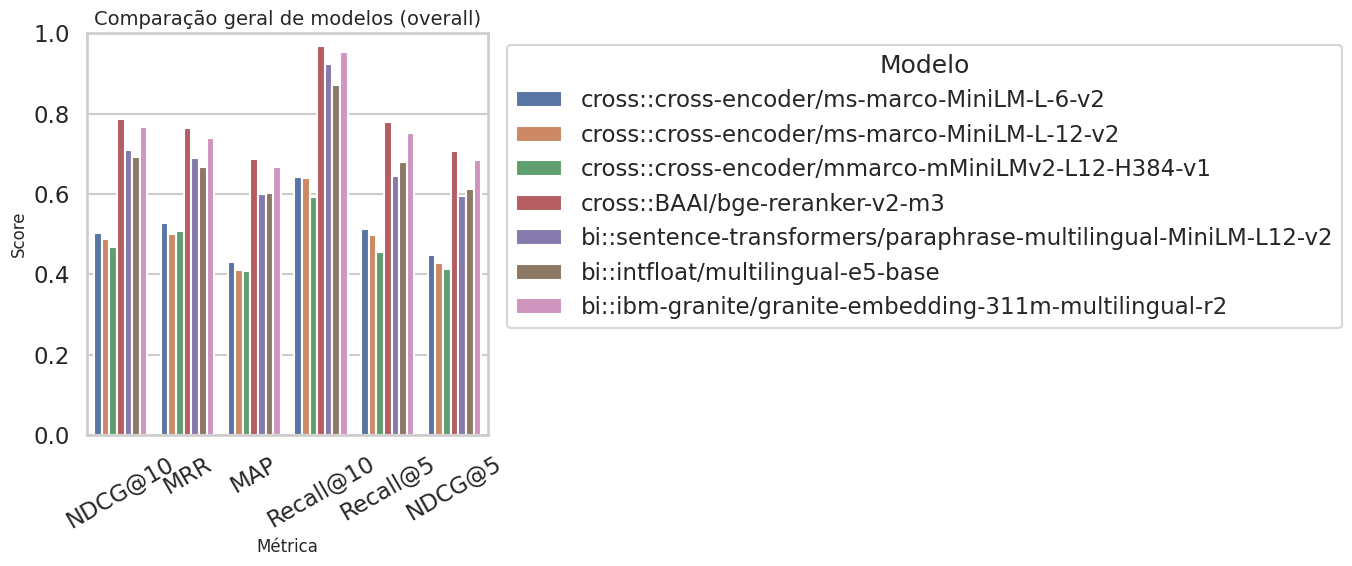

In [19]:
# Setup de visualização + comparação geral (overall)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

if "results_df" not in globals() or results_df.empty:
    raise ValueError("results_df não encontrado. Execute as células de benchmark primeiro.")

metric_priority = ["NDCG@10", "MRR", "MAP", "Recall@10", "Recall@5", "NDCG@5"]
available_metrics = [m for m in metric_priority if m in results_df.columns]

overall_plot_df = results_df[results_df["query_type"] == "overall"].copy()
if overall_plot_df.empty:
    raise ValueError("Sem linha 'overall' em results_df.")

display_cols = ["model"] + available_metrics
display(
    overall_plot_df[display_cols].sort_values("NDCG@10", ascending=False)
    if "NDCG@10" in available_metrics
    else overall_plot_df[display_cols]
)

overall_long = overall_plot_df.melt(
    id_vars=["model", "query_type"],
    value_vars=available_metrics,
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=overall_long, x="metric", y="score", hue="model")
ax.set_title("Comparação geral de modelos (overall)")
ax.set_xlabel("Métrica")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [20]:
# Heatmap por tipo de query
type_df = results_df[results_df["query_type"] != "overall"].copy()
if type_df.empty:
    raise ValueError("Sem dados por tipo de query em results_df.")

metric_for_heatmap = "NDCG@10" if "NDCG@10" in type_df.columns else available_metrics[0]
heatmap_df = type_df.pivot(index="model", columns="query_type", values=metric_for_heatmap)


## Visualizações e melhores modelos por tipo de query

> Esta seção mostra:
- comparação geral entre modelos
- desempenho por tipo de query
- melhor modelo para cada tipo de query em diferentes métricas

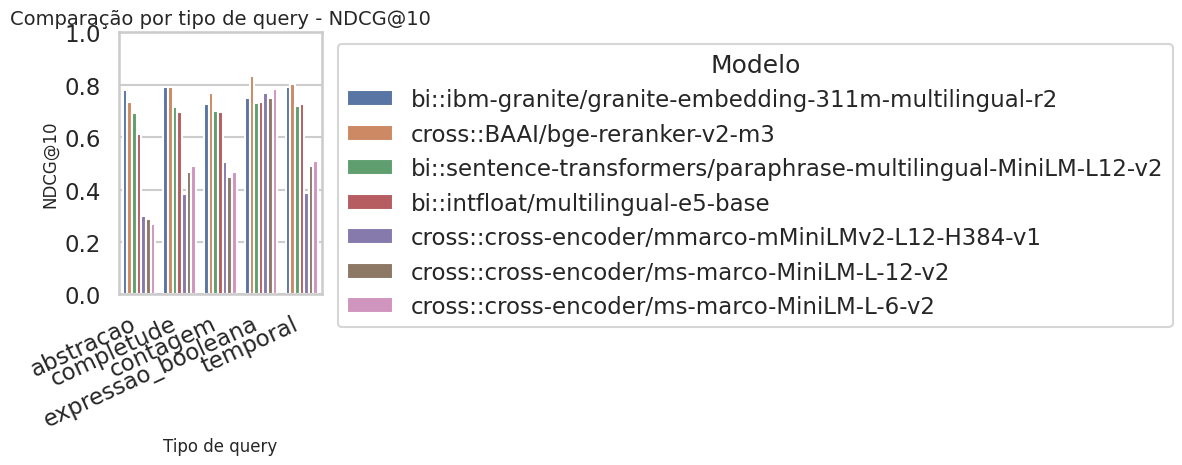

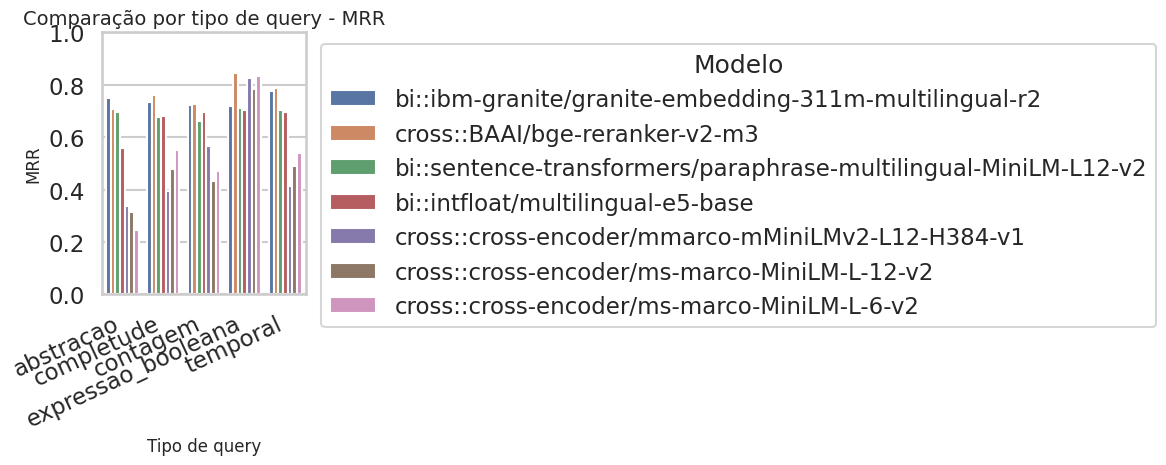

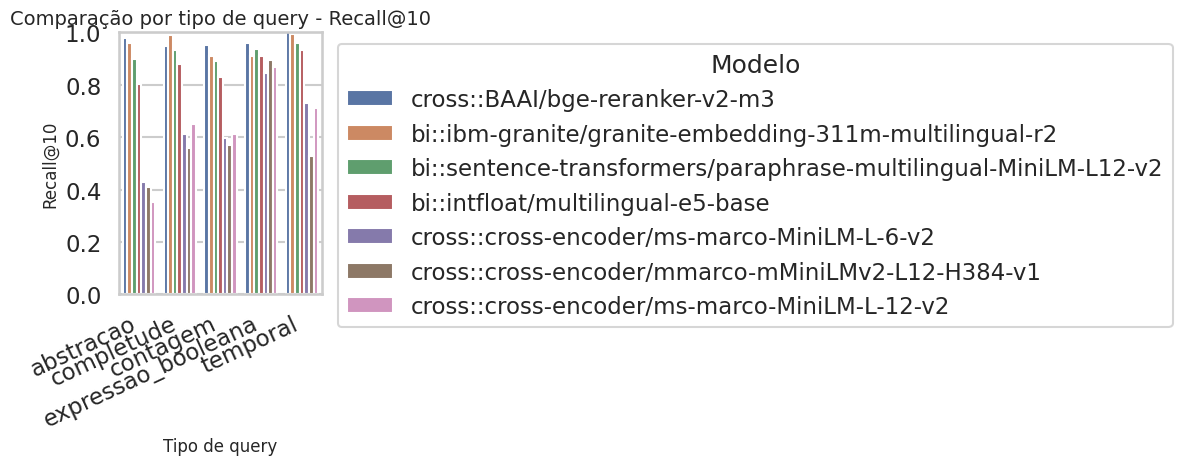

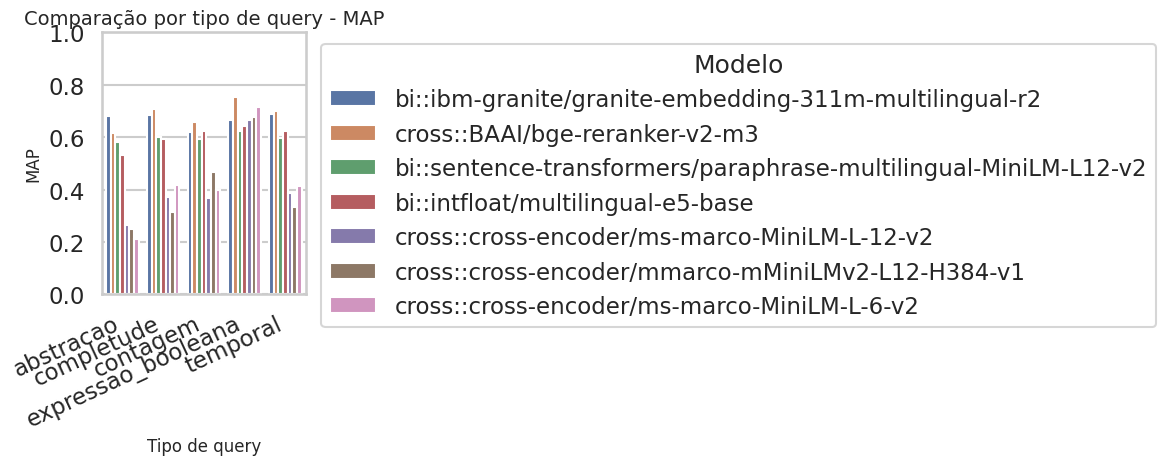

In [21]:
# Gráfico por métrica: barras por tipo de query
type_df = results_df[results_df["query_type"] != "overall"].copy()
if type_df.empty:
    raise ValueError("Sem dados por tipo de query em results_df.")

candidate_metrics = [m for m in ["NDCG@10", "MRR", "Recall@10", "MAP"] if m in type_df.columns]

for metric in candidate_metrics:
    plt.figure(figsize=(12, 5))
    metric_plot_df = type_df[["query_type", "model", metric]].copy()
    metric_plot_df = metric_plot_df.sort_values(["query_type", metric], ascending=[True, False])

    ax = sns.barplot(data=metric_plot_df, x="query_type", y=metric, hue="model")
    ax.set_title(f"Comparação por tipo de query - {metric}")
    ax.set_xlabel("Tipo de query")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    plt.xticks(rotation=25, ha="right")
    plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

,model,wins
1,cross::BAAI/bge-reranker-v2-m3,16
0,bi::ibm-granite/granite-embedding-311m-multili...,4


/tmp/ipykernel_11933/3826732837.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=wins_df, x="wins", y="model", palette="viridis")


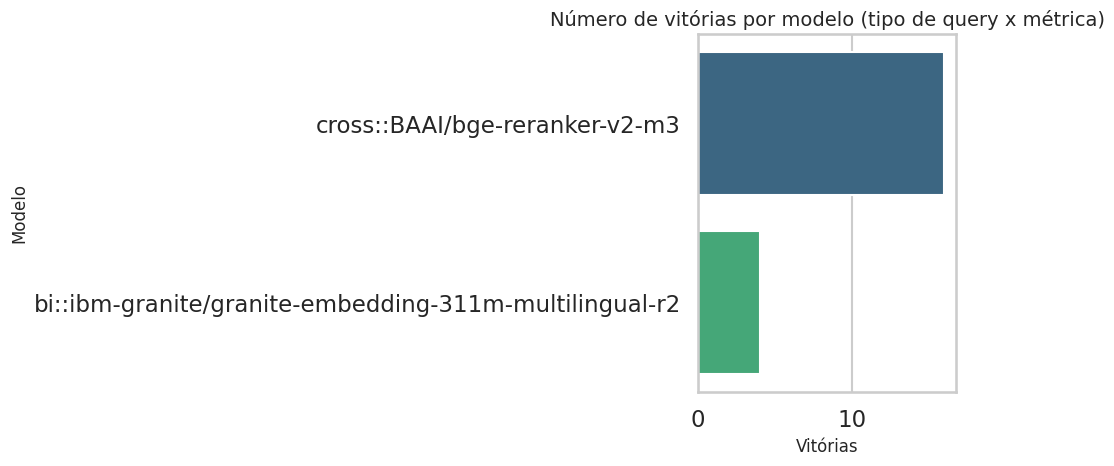

In [22]:
# Ranking de vitórias: melhor modelo por tipo+métrica
best_df_local = None
tmp_best = globals().get("best_per_type_df", None)

if isinstance(tmp_best, pd.DataFrame) and not tmp_best.empty:
    best_df_local = tmp_best.copy()
else:
    type_df = results_df[results_df["query_type"] != "overall"].copy()
    candidate_metrics = [m for m in ["NDCG@10", "MRR", "Recall@10", "MAP"] if m in type_df.columns]

    best_rows = []
    for metric in candidate_metrics:
        idx = type_df.groupby("query_type")[metric].idxmax()
        best_metric_df = type_df.loc[idx, ["query_type", "model", metric]].copy()
        best_metric_df = best_metric_df.rename(columns={"model": "best_model", metric: "score"})
        best_metric_df["metric"] = metric
        best_rows.append(best_metric_df)

    best_df_local = pd.concat(best_rows, ignore_index=True)
    best_df_local = best_df_local[["metric", "query_type", "best_model", "score"]].sort_values(["metric", "query_type"] )

wins_df = (
    best_df_local.groupby("best_model", as_index=False)
    .size()
    .rename(columns={"best_model": "model", "size": "wins"})
    .sort_values("wins", ascending=False)
)
display(wins_df)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=wins_df, x="wins", y="model", palette="viridis")
ax.set_title("Número de vitórias por modelo (tipo de query x métrica)")
ax.set_xlabel("Vitórias")
ax.set_ylabel("Modelo")
plt.tight_layout()
plt.show()

In [23]:
# Melhor modelo por tipo de query em múltiplas métricas
type_df = results_df[results_df["query_type"] != "overall"].copy()
if type_df.empty:
    raise ValueError("Sem dados por tipo de query em results_df.")

candidate_metrics = [m for m in ["NDCG@10", "MRR", "Recall@10", "MAP"] if m in type_df.columns]

best_rows = []
for metric in candidate_metrics:
    idx = type_df.groupby("query_type")[metric].idxmax()
    best_metric_df = type_df.loc[idx, ["query_type", "model", metric]].copy()
    best_metric_df = best_metric_df.rename(columns={"model": "best_model", metric: "score"})
    best_metric_df["metric"] = metric
    best_rows.append(best_metric_df)

best_per_type_df = pd.concat(best_rows, ignore_index=True)
best_per_type_df = best_per_type_df[["metric", "query_type", "best_model", "score"]].sort_values(["metric", "query_type"])
display(best_per_type_df)

,metric,query_type,best_model,score
15,MAP,abstracao,bi::ibm-granite/granite-embedding-311m-multili...,0.681439
16,MAP,completude,cross::BAAI/bge-reranker-v2-m3,0.706949
17,MAP,contagem,cross::BAAI/bge-reranker-v2-m3,0.658750
18,MAP,expressao_booleana,cross::BAAI/bge-reranker-v2-m3,0.752063
19,MAP,temporal,cross::BAAI/bge-reranker-v2-m3,0.698063
5,MRR,abstracao,bi::ibm-granite/granite-embedding-311m-multili...,0.748333
6,MRR,completude,cross::BAAI/bge-reranker-v2-m3,0.762381
7,MRR,contagem,cross::BAAI/bge-reranker-v2-m3,0.726667
8,MRR,expressao_booleana,cross::BAAI/bge-reranker-v2-m3,0.844000
9,MRR,temporal,cross::BAAI/bge-reranker-v2-m3,0.786333
